# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. Sumber Dataset:  
   Dataset yang digunakan pada project ini adalah Stroke Prediction Dataset yang diperoleh dari Kaggle.

Dataset source:
https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset

Dataset ini digunakan untuk memprediksi kemungkinan seseorang mengalami stroke berdasarkan beberapa faktor kesehatan seperti:
- usia,
- hipertensi,
- penyakit jantung,
- kadar glukosa,
- BMI,
- status merokok,
- dan faktor lainnya.

Dataset memiliki target:
- stroke
dengan:
- 0 = tidak stroke
- 1 = stroke

Jenis permasalahan:
Binary Classification.

Alasan memilih dataset:
- cocok untuk implementasi machine learning,
- memiliki fitur numerik dan kategorikal,
- cocok untuk preprocessing,
- cocok untuk monitoring dan deployment MLOps.




# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
df = pd.read_csv('../dataset_raw/healthcare-dataset-stroke-data.csv')

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

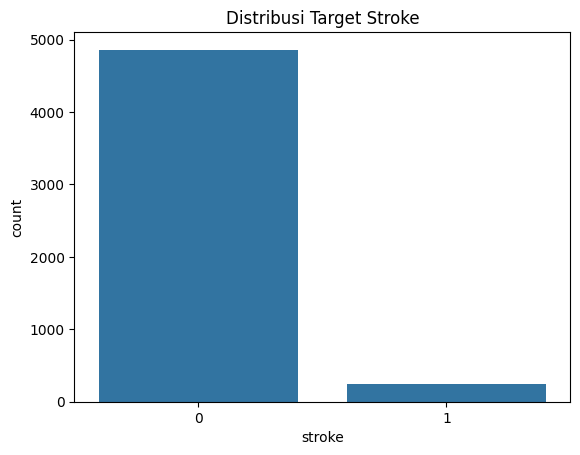

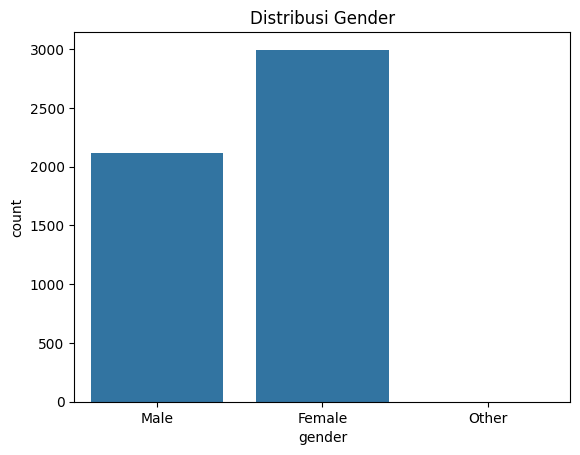

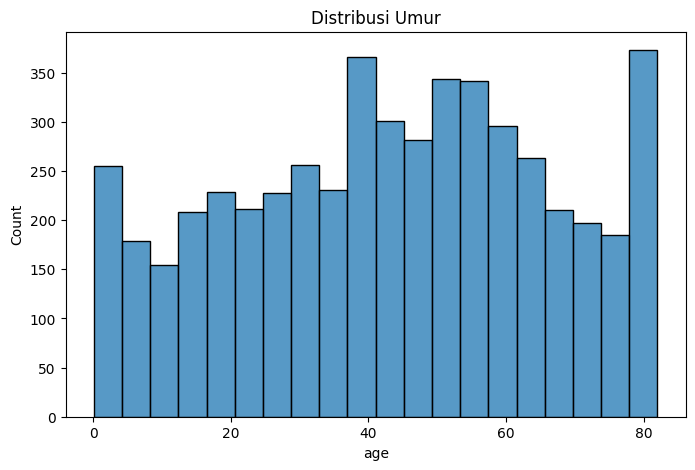

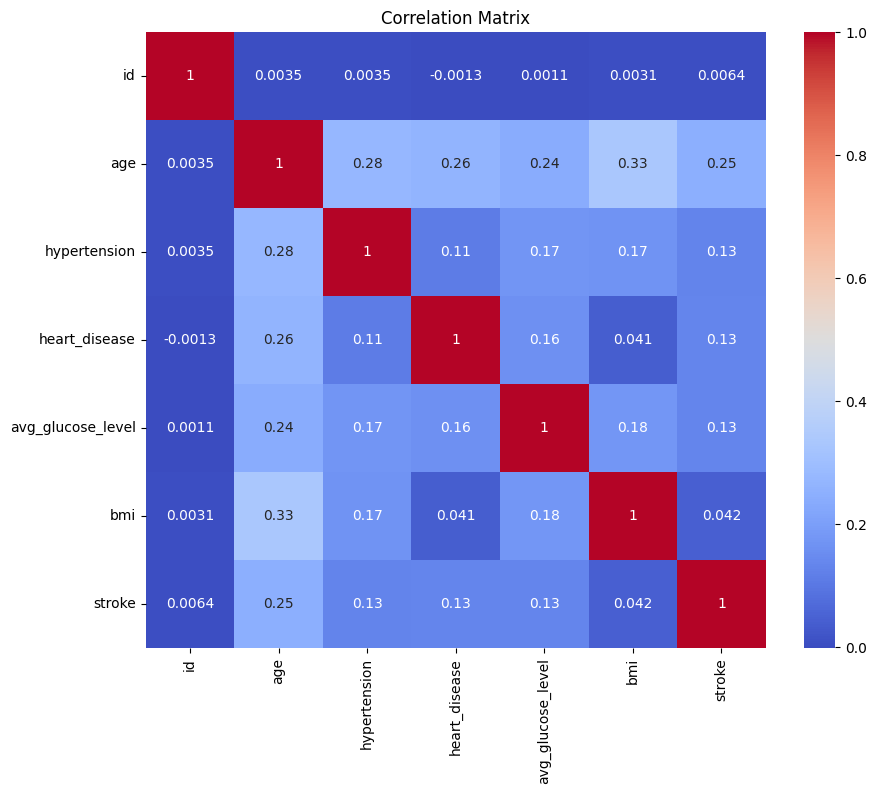

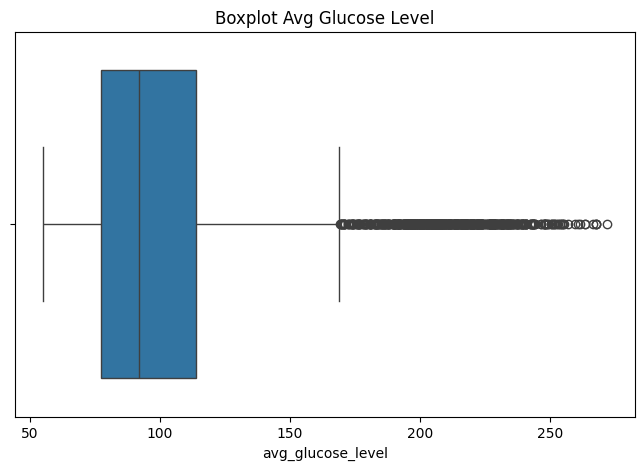

In [6]:
df.describe()
df.isnull().sum()
sns.countplot(x='stroke', data=df)

plt.title('Distribusi Target Stroke')

plt.show()

sns.countplot(x='gender', data=df)

plt.title('Distribusi Gender')

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20)

plt.title('Distribusi Umur')

plt.show()

plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

plt.figure(figsize=(8,5))

sns.boxplot(x=df['avg_glucose_level'])

plt.title('Boxplot Avg Glucose Level')

plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
df = df.drop('id', axis=1)

df.duplicated().sum()

df = df.drop_duplicates()

categorical_cols = df.select_dtypes(include='object').columns

imputer = SimpleImputer(strategy='most_frequent')

df[categorical_cols] = imputer.fit_transform(df[categorical_cols])

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

    X = df.drop('stroke', axis=1)

y = df['stroke']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(4088, 10)
(1022, 10)
(4088,)
(1022,)
